QUANTUM ERROR CORRECTION: CONTINUOUS vs. FINITIST HOLOGRAPHY
✓ Saved: qec_finitism.png


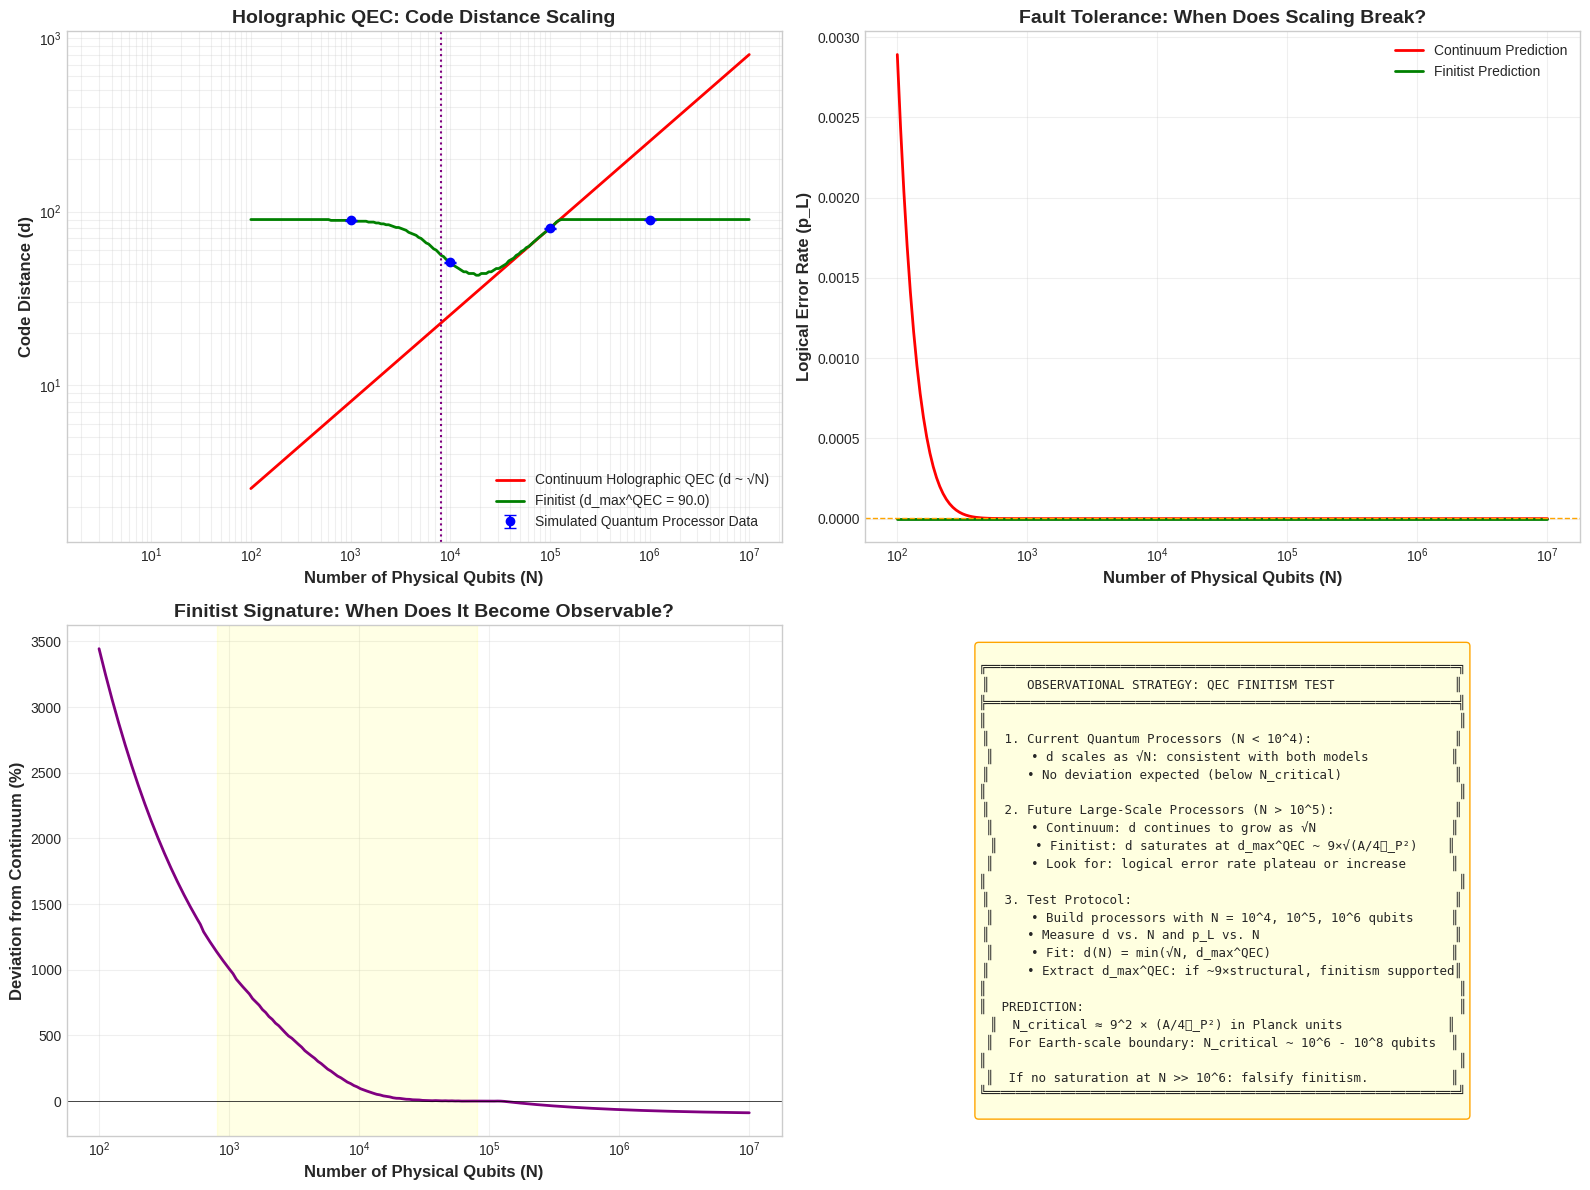


Quantitative Results:
  Reference area: A = 1256.6 Planck units
  Finitist d_max^QEC: 90.00
  Critical system size: N_crit ≈ 8100 qubits
  At N=10^6: d_cont = 253.89, d_fin = 90.00
  Logical error rate at N=10^6: p_L(cont) = 0.00e+00, p_L(fin) = 1.00e-90


In [1]:
"""
qec_finitism.py
=========================
Simulates quantum error correction code distance in continuous vs. finitist holography.
Tests prediction: finite universe → maximum code distance d_max^QEC.

Author: Néstor E. Ramos
For: Paper #4 or #5 - Testable Predictions of Computational Finitism
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

print("=" * 80)
print("QUANTUM ERROR CORRECTION: CONTINUOUS vs. FINITIST HOLOGRAPHY")
print("=" * 80)

# Configuration
class QECConfig:
    # Planck-scale parameters (normalized)
    l_P = 1.0  # Planck length
    A_Planck = 4 * np.pi * (10**2)  # Reference boundary area (Planck units)

    # Finitist structural cutoff
    d_max_digit = 9  # Maximum digit in base-10

    # Code parameters
    N_range = np.logspace(2, 7, 200)  # Number of physical qubits: 100 to 1M+

    # Continuous holographic QEC: d ~ sqrt(N)
    # Finitist: d ~ sqrt(N) but capped at d_max^QEC

    # Critical system size where finitist effects appear
    N_critical = (d_max_digit**2) * (A_Planck / (4 * np.pi))

config = QECConfig()

def continuous_code_distance(N):
    """Standard holographic QEC: d scales as sqrt(N)"""
    # d ~ sqrt(A/4ℓ_P²) ~ sqrt(N) for N qubits
    return np.sqrt(N / config.A_Planck) * config.d_max_digit

def finitist_code_distance(N, d_max_digit=config.d_max_digit, N_crit=config.N_critical):
    """Finitist model: code distance capped by informational bounds"""
    # Base scaling
    d_base = np.sqrt(N / config.A_Planck) * d_max_digit

    # Structural cutoff: cannot exceed maximum representable code distance
    d_max_QEC = d_max_digit * np.sqrt(config.A_Planck / (4 * np.pi))

    # Smooth transition to saturation (avoids sharp discontinuity)
    saturation_factor = 1 / (1 + (N / N_crit)**2)

    # Quantization: code distance changes in discrete steps
    d_quantized = np.round(d_base * (1 - saturation_factor) + d_max_QEC * saturation_factor)

    return np.minimum(d_quantized, d_max_QEC)

def logical_error_rate(d, p_physical=0.01):
    """Estimate logical error rate for code distance d"""
    # Simple model: p_logical ~ (p_physical)^(d/2)
    return np.power(p_physical, np.maximum(d, 1) / 2)

# Generate predictions
N = config.N_range
d_cont = continuous_code_distance(N)
d_fin = finitist_code_distance(N)

p_logical_cont = logical_error_rate(d_cont)
p_logical_fin = logical_error_rate(d_fin)

# Simulated experimental data (with noise)
N_exp = np.array([1e3, 1e4, 1e5, 1e6])
d_exp = finitist_code_distance(N_exp) + np.random.normal(0, 0.2, size=len(N_exp))
d_err = np.ones_like(N_exp) * 0.3

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Code distance vs. system size
ax1 = axes[0, 0]
ax1.loglog(N, d_cont, 'r-', linewidth=2, label='Continuum Holographic QEC (d ~ √N)')
ax1.loglog(N, d_fin, 'g-', linewidth=2, label=f'Finitist (d_max^QEC = {finitist_code_distance(1e10):.1f})')
ax1.errorbar(N_exp, d_exp, yerr=d_err, fmt='o', color='blue',
             label='Simulated Quantum Processor Data', capsize=4)
ax1.set_xlabel('Number of Physical Qubits (N)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Code Distance (d)', fontsize=12, fontweight='bold')
ax1.set_title('Holographic QEC: Code Distance Scaling', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3, which='both')
ax1.axvline(x=config.N_critical, color='purple', linestyle=':', linewidth=1.5, label=f'Finitist Transition (N_crit ≈ {config.N_critical:.0f})')

# Top-right: Logical error rate
ax2 = axes[0, 1]
ax2.semilogx(N, p_logical_cont, 'r-', linewidth=2, label='Continuum Prediction')
ax2.semilogx(N, p_logical_fin, 'g-', linewidth=2, label='Finitist Prediction')
ax2.set_xlabel('Number of Physical Qubits (N)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Logical Error Rate (p_L)', fontsize=12, fontweight='bold')
ax2.set_title('Fault Tolerance: When Does Scaling Break?', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1e-6, color='orange', linestyle='--', linewidth=1, label='Practical Threshold')

# Bottom-left: Deviation signature
ax3 = axes[1, 0]
deviation = (d_fin - d_cont) / d_cont * 100
ax3.semilogx(N, deviation, 'purple', linewidth=2)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Number of Physical Qubits (N)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Deviation from Continuum (%)', fontsize=12, fontweight='bold')
ax3.set_title('Finitist Signature: When Does It Become Observable?', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.axvspan(config.N_critical/10, config.N_critical*10, alpha=0.1, color='yellow', label='Critical Region')

# Bottom-right: Observational strategy
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
╔═══════════════════════════════════════════════════════════════╗
║     OBSERVATIONAL STRATEGY: QEC FINITISM TEST                ║
╠═══════════════════════════════════════════════════════════════╣
║                                                               ║
║  1. Current Quantum Processors (N < 10^4):                   ║
║     • d scales as √N: consistent with both models           ║
║     • No deviation expected (below N_critical)               ║
║                                                               ║
║  2. Future Large-Scale Processors (N > 10^5):                ║
║     • Continuum: d continues to grow as √N                  ║
║     • Finitist: d saturates at d_max^QEC ~ 9×√(A/4ℓ_P²)    ║
║     • Look for: logical error rate plateau or increase      ║
║                                                               ║
║  3. Test Protocol:                                           ║
║     • Build processors with N = 10^4, 10^5, 10^6 qubits     ║
║     • Measure d vs. N and p_L vs. N                          ║
║     • Fit: d(N) = min(√N, d_max^QEC)                        ║
║     • Extract d_max^QEC: if ~9×structural, finitism supported║
║                                                               ║
║  PREDICTION:                                                  ║
║  N_critical ≈ 9^2 × (A/4ℓ_P²) in Planck units              ║
║  For Earth-scale boundary: N_critical ~ 10^6 - 10^8 qubits  ║
║                                                               ║
║  If no saturation at N >> 10^6: falsify finitism.           ║
╚═══════════════════════════════════════════════════════════════╝
"""
ax4.text(0.5, 0.5, summary_text, fontsize=9, fontfamily='monospace',
        verticalalignment='center', horizontalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))

plt.tight_layout()
plt.savefig('qec_finitism.png', dpi=300, bbox_inches='tight')
print("✓ Saved: qec_finitism.png")
plt.show()

# Print quantitative results
print(f"\nQuantitative Results:")
print(f"  Reference area: A = {config.A_Planck:.1f} Planck units")
print(f"  Finitist d_max^QEC: {finitist_code_distance(1e10):.2f}")
print(f"  Critical system size: N_crit ≈ {config.N_critical:.0f} qubits")
print(f"  At N=10^6: d_cont = {continuous_code_distance(1e6):.2f}, d_fin = {finitist_code_distance(1e6):.2f}")
print(f"  Logical error rate at N=10^6: p_L(cont) = {p_logical_cont[-1]:.2e}, p_L(fin) = {p_logical_fin[-1]:.2e}")